In [1]:
%load_ext autoreload
%autoreload 2

from folde.util import load_checkpointed_model_eval, convert_compaign_result_collection_to_df, DMS_SHORTNAMES

# Load naturalness model data
naturalness_results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250713-naturalness-param-scan',
    []
)
_, naturalness_round_metrics_df = convert_compaign_result_collection_to_df(naturalness_results)
naturalness_round_metrics_df['dms_shortname'] = naturalness_round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

# Load embedding model data
embedding_results = load_checkpointed_model_eval(
    'notebooks/jacob/model_evals/',
    '250720-embedding-param-scan',
    []
)
_, embedding_round_metrics_df = convert_compaign_result_collection_to_df(embedding_results)
embedding_round_metrics_df['dms_shortname'] = embedding_round_metrics_df.dms_id.apply(lambda x: DMS_SHORTNAMES[x])

Loading results for DMSs: {'BLAT_ECOLX_Firnberg_2014', 'HXK4_HUMAN_Gersing_2022_activity', 'CBS_HUMAN_Sun_2020', 'ANCSZ_Hobbs_2022', 'HEM3_HUMAN_Loggerenberg_2023', 'OXDA_RHOTO_Vanella_2023_activity', 'SHOC2_HUMAN_Kwon_2022', 'HSP82_YEAST_Flynn_2019', 'PPM1D_HUMAN_Miller_2022'}
Loading results for DMSs: {'BLAT_ECOLX_Firnberg_2014', 'HXK4_HUMAN_Gersing_2022_activity', 'CBS_HUMAN_Sun_2020', 'ANCSZ_Hobbs_2022', 'HEM3_HUMAN_Loggerenberg_2023', 'OXDA_RHOTO_Vanella_2023_activity', 'SHOC2_HUMAN_Kwon_2022', 'HSP82_YEAST_Flynn_2019', 'PPM1D_HUMAN_Miller_2022'}


/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_18442/779573759.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_18442/779573759.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([c[1] for c in model_name_list], rotation=45, ha='right')
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_18442/779573759.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/p6/jn7zk09154v2f60d993vb2sm0000gn/T/ipykernel_18442/779573759.py:71: UserWarning: set_ticklabels() should only be used with a fixed number

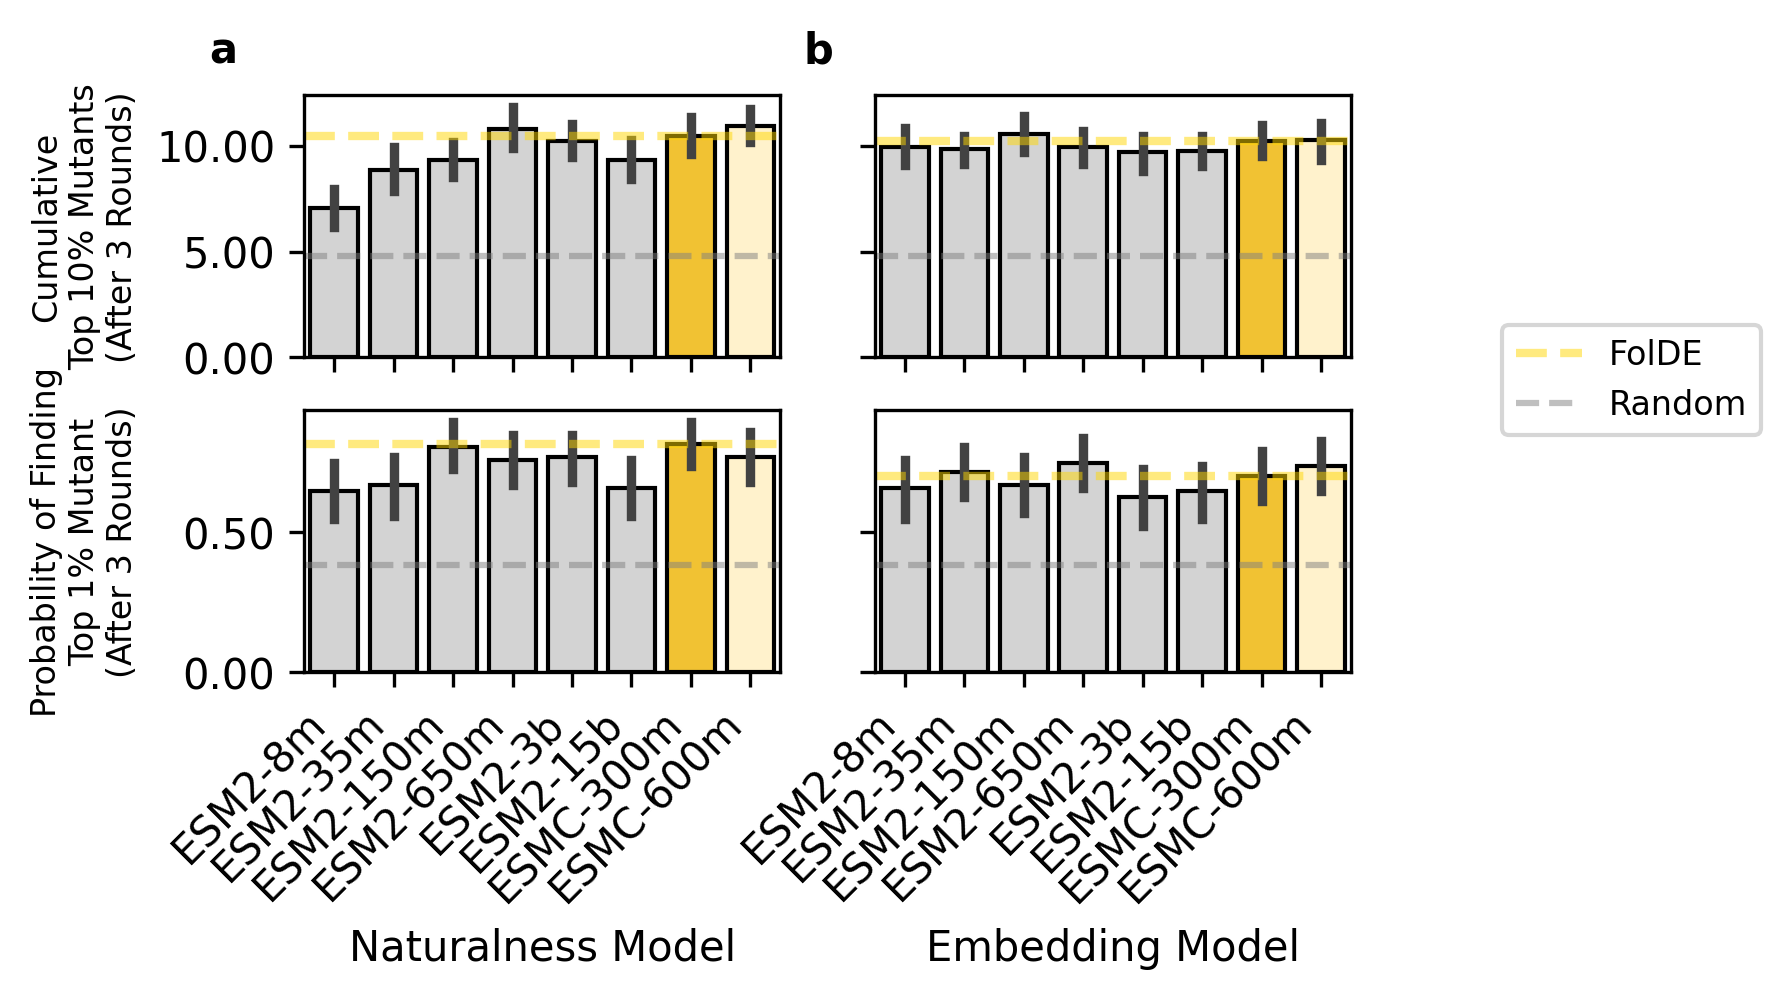

In [4]:
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import sys
from notebooks.jacob.paperplots.util import get_random_baseline_number_of_top_performers, get_random_baseline_probability_of_top_performer

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(4.5, 2.5), sharex='col', sharey='row', dpi=300)

PLOT_TYPE = 'bar'

model_name_list = [
    ('FolDE-8m', 'ESM2-8m'),
    ('FolDE-35m', 'ESM2-35m'),
    ('FolDE-150m', 'ESM2-150m'),
    ('FolDE-650m', 'ESM2-650m'),
    ('FolDE-3b', 'ESM2-3b'),
    ('FolDE-15b', 'ESM2-15b'),
    ('FolDE-300m', 'ESMC-300m'),
    ('FolDE-600m', 'ESMC-600m'),
]

def name_to_size(name):
    if not re.match(r'.*-\d+[bm]', name):
        return 0.0
    sizestr = name.split('-')[1]
    size = float(sizestr[:-1])
    if sizestr.endswith('b'):
        size *= 1e9
    elif sizestr.endswith('m'):
        size *= 1e6
    return size

def get_color(model_name):
    if model_name.startswith('ESM2'):
        return 'lightgrey'
    elif model_name == 'ESMC-300m':
        return '#F1C233'
    else:
        return '#FFF2CC'

model_name_map = {k: v for k, v in model_name_list}

# Prepare naturalness data
naturalness_df = naturalness_round_metrics_df[naturalness_round_metrics_df.round_num == 3].copy()
naturalness_df = naturalness_df[naturalness_df.config_name.isin([c[0] for c in model_name_list])]
naturalness_df['model_name'] = naturalness_df.config_name.apply(lambda x: model_name_map[x])
naturalness_df['Model Family'] = naturalness_df.model_name.apply(lambda x: x.split('-')[0])
naturalness_df['Model Size'] = naturalness_df.model_name.apply(name_to_size)

# Prepare embedding data
embedding_df = embedding_round_metrics_df[embedding_round_metrics_df.round_num == 3].copy()
embedding_df = embedding_df[embedding_df.config_name.isin([c[0] for c in model_name_list])]
embedding_df['model_name'] = embedding_df.config_name.apply(lambda x: model_name_map[x])
embedding_df['Model Family'] = embedding_df.model_name.apply(lambda x: x.split('-')[0])
embedding_df['Model Size'] = embedding_df.model_name.apply(name_to_size)

# Plot naturalness models (left column)
for ax, metric in zip([ax1, ax3], ['cumulative_10pct_hits', 'has_found_top_1pct']):
    sns.barplot(
        data=naturalness_df,
        x='model_name',
        y=metric,
        order=[c[1] for c in model_name_list],
        palette={c[1]: get_color(c[1]) for c in model_name_list},
        ax=ax,
        edgecolor='black',
        linewidth=1.0,
        saturation=1.0
    )
    ax.set_xticklabels([c[1] for c in model_name_list], rotation=45, ha='right')
    
    # Add FolDE baseline
    baseline_y = naturalness_df[naturalness_df.model_name == 'ESMC-300m'][metric].mean()
    ax.axhline(y=baseline_y, color='gold', linestyle='--', linewidth=2, alpha=0.5, label='FolDE')
    
    # Add random baseline
    if metric == 'cumulative_10pct_hits':
        random_baseline = get_random_baseline_number_of_top_performers(16, 3, 0.10)
    elif metric == 'has_found_top_1pct':
        random_baseline = get_random_baseline_probability_of_top_performer(16, 3, 0.01)
    ax.axhline(y=random_baseline, color='grey', linestyle='--', linewidth=1.5, alpha=0.5, label='Random')
    
    if metric == 'cumulative_10pct_hits':
        ax.set_ylabel('Cumulative\nTop 10% Mutants\n(After 3 Rounds)', fontsize=8)
    elif metric == 'has_found_top_1pct':
        ax.set_ylabel('Probability of Finding\nTop 1% Mutant\n(After 3 Rounds)', fontsize=8)
    
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

# Plot embedding models (right column)
for ax, metric in zip([ax2, ax4], ['cumulative_10pct_hits', 'has_found_top_1pct']):
    sns.barplot(
        data=embedding_df,
        x='model_name',
        y=metric,
        order=[c[1] for c in model_name_list],
        palette={c[1]: get_color(c[1]) for c in model_name_list},
        ax=ax,
        edgecolor='black',
        linewidth=1.0,
        saturation=1.0
    )
    ax.set_xticklabels([c[1] for c in model_name_list], rotation=45, ha='right')
    
    # Add FolDE baseline
    baseline_y = embedding_df[embedding_df.model_name == 'ESMC-300m'][metric].mean()
    ax.axhline(y=baseline_y, color='gold', linestyle='--', linewidth=2, alpha=0.5, label='FolDE')
    
    # Add random baseline
    if metric == 'cumulative_10pct_hits':
        random_baseline = get_random_baseline_number_of_top_performers(16, 3, 0.10)
    elif metric == 'has_found_top_1pct':
        random_baseline = get_random_baseline_probability_of_top_performer(16, 3, 0.01)
    ax.axhline(y=random_baseline, color='grey', linestyle='--', linewidth=1.5, alpha=0.5, label='Random')
    
    ax.set_ylabel('')
    ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f'))

# Add panel labels - positioned at the top left corner of each column
ax1.text(-0.20, 1.25, 'a', transform=ax1.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')
ax2.text(-0.15, 1.25, 'b', transform=ax2.transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

# Set x-labels
ax1.set_xlabel('')
ax2.set_xlabel('')
ax3.set_xlabel('Naturalness Model')
ax4.set_xlabel('Embedding Model')

# Add legend to the right
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8, frameon=True)

fig.align_ylabels([ax1, ax3])
# plt.tight_layout()

plt.savefig('notebooks/jacob/paperplots/sup_plm_selection.png', dpi=300, bbox_inches='tight')